In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [104]:
df = pd.read_csv("elecequip.csv")
df.head()

,date,value
0,01/01/96,79.35
1,01/02/96,75.78
2,01/03/96,86.32
3,01/04/96,72.60
4,01/05/96,74.86


<AxesSubplot: >

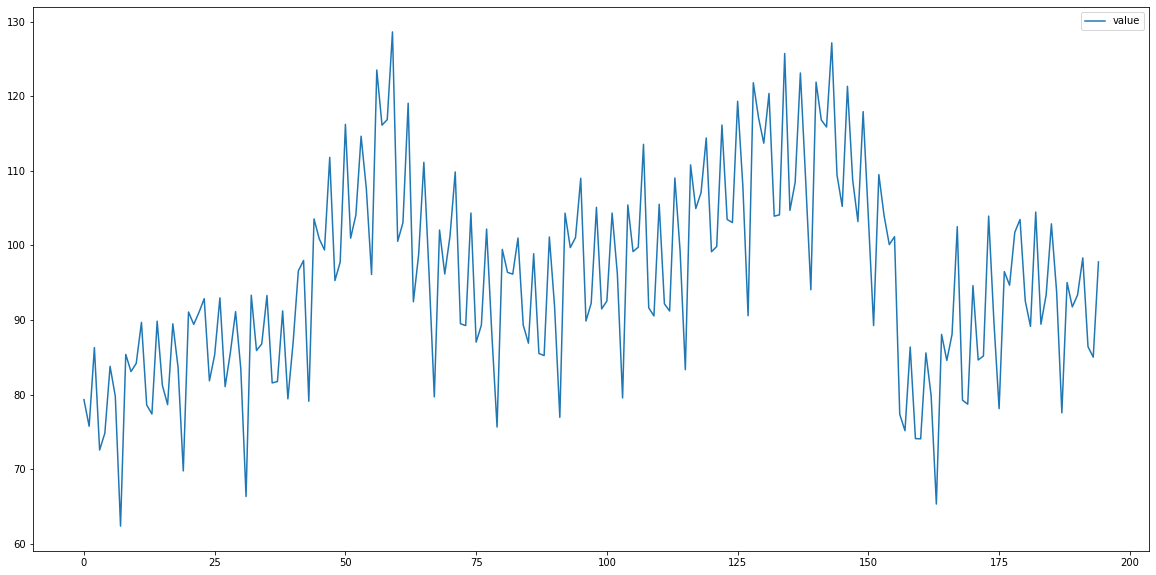

In [90]:
df.plot()

In [106]:
df['date'] = pd.to_datetime(df['date'], format="%d/%m/%y")

In [107]:
df.head()

,date,value
0,1996-01-01,79.35
1,1996-02-01,75.78
2,1996-03-01,86.32
3,1996-04-01,72.60
4,1996-05-01,74.86


In [105]:
df.dtypes

date      object
value    float64
dtype: object

In [108]:
df['month']  = df.date.dt.month
df['year']  = df.date.dt.year

In [109]:
df.head()

,date,value,month,year
0,1996-01-01,79.35,1,1996
1,1996-02-01,75.78,2,1996
2,1996-03-01,86.32,3,1996
3,1996-04-01,72.60,4,1996
4,1996-05-01,74.86,5,1996


In [110]:
df_1 = df.set_index('date')

In [111]:
df_1.head()

,value,month,year
date,,,
1996-01-01,79.35,1,1996
1996-02-01,75.78,2,1996
1996-03-01,86.32,3,1996
1996-04-01,72.60,4,1996
1996-05-01,74.86,5,1996


In [112]:
df_1.dtypes

value    float64
month      int64
year       int64
dtype: object

In [135]:
def decompose(df, column_name):
    """
    A function that returns the trend, seasonality and residual captured by applying both multiplicative and
    additive model.
    df -> DataFrame
    column_name -> column_name for which trend, seasonality is to be captured
    """
    result_mul = seasonal_decompose(df[column_name], model='multiplicative',  period=6)
    result_add = seasonal_decompose(df[column_name], model = 'additive', extrapolate_trend='freq', period=6)

    plt.rcParams.update({'figure.figsize': (20, 10)})
    result_mul.plot().suptitle('Multiplicative Decompose', fontsize=30)
    result_add.plot().suptitle('Additive Decompose', fontsize=30)
    plt.show()
    
    return result_mul, result_add

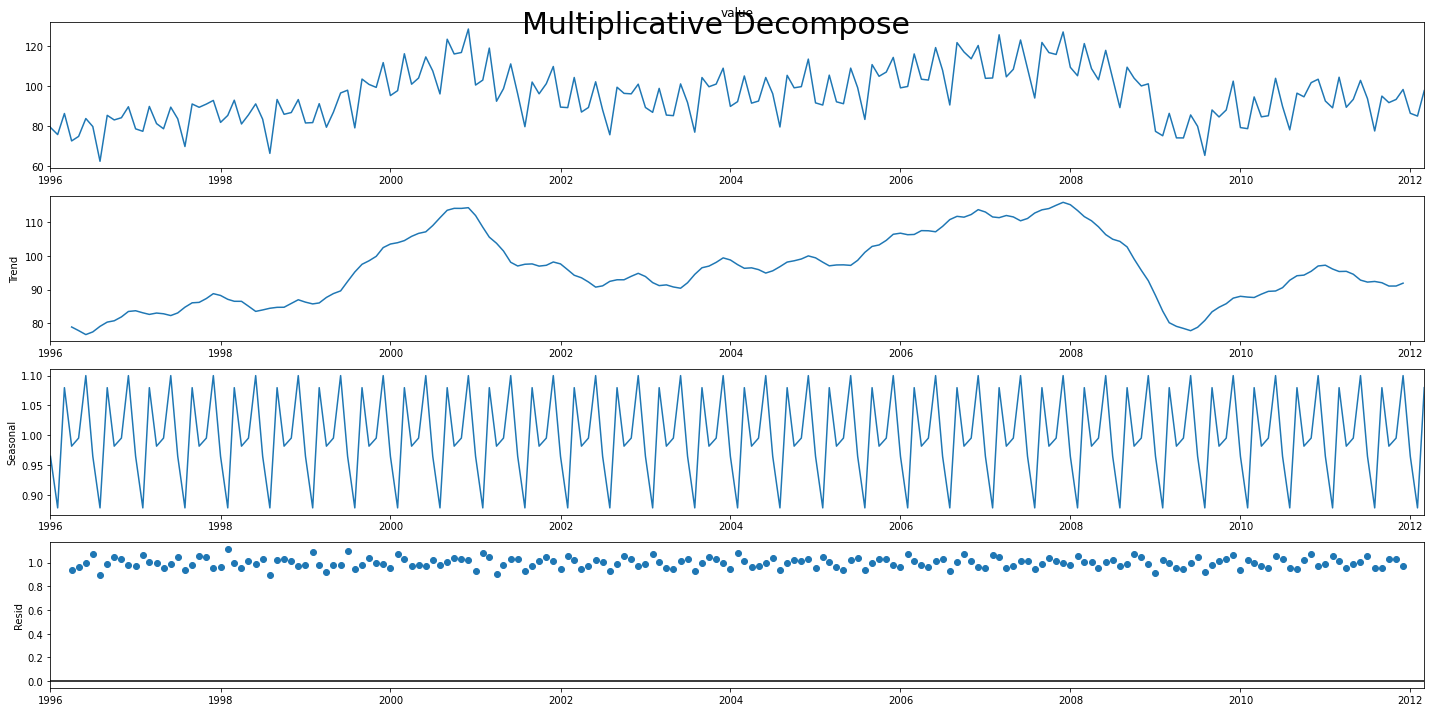

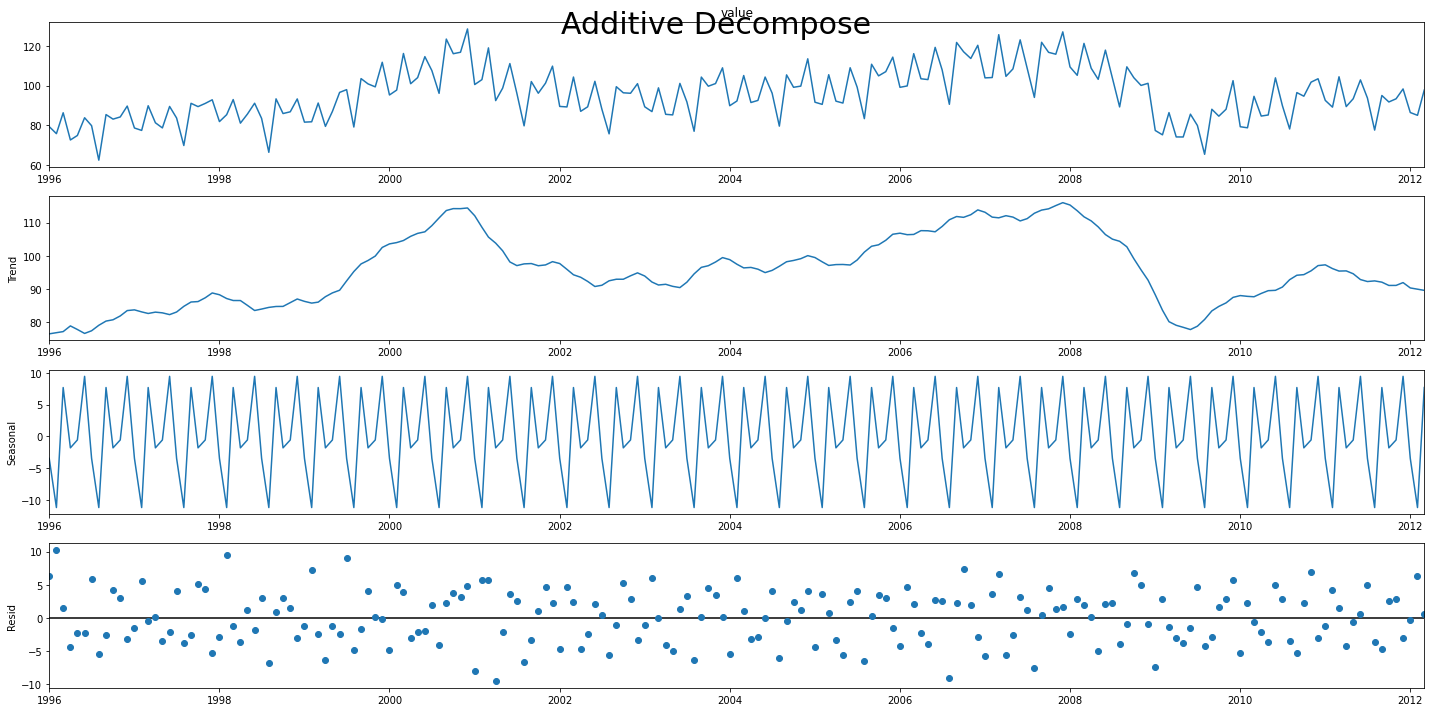

In [136]:
result_mul, result_add = decompose(df_1, 'value')

In [125]:
df.head()

,date,value,month,year
0,1996-01-01,79.35,1,1996
1,1996-02-01,75.78,2,1996
2,1996-03-01,86.32,3,1996
3,1996-04-01,72.60,4,1996
4,1996-05-01,74.86,5,1996


In [126]:
import seaborn as sns

In [129]:
# create color mapping based on all unique values of year
years = df_1.index.year.unique()
colors = sns.color_palette('husl', n_colors=len(years))  # get a number of colors
cmap = dict(zip(years, colors))  # zip values to colors

for k, v in df_1.groupby('month'):  # group the dateframe by month
    plt.figure(figsize=(16, 10))
    for year in v.index.year.unique():  # withing the month plot each year
        data = v[v.index.year == year]
        sns.lineplot(data.index.month, data.value, err_style=None, hue=year, palette=cmap)
    plt.xlim(0, 33)
    plt.xticks(range(1, 32))
    plt.title(f'Month: {k}')
    plt.xlabel('Day of Month')
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.show()

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 3 keyword-only arguments) were given

<Figure size 1152x720 with 0 Axes>

In [130]:
for k, v in df_1.groupby('month'):  # group the dateframe by month
    plt.figure(figsize=(16, 10))
    for year in v.index.year.unique():  # withing the month plot each year
        data = v[v.index.year == year]
        print(data.index.month)

Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([1], dtype='int64', name='date')
Int64Index([2], dtype='int64', name='date')
Int64Index([2], dtype='int64', name='date')
Int64Index([2], dtype='int64', name='date')
Int64Index([2], dtype='int64', name='date')
Int64Index([2], dtype='int64', name='date')
Int64Index([2], dtype='int64', n

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

...

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>

<Figure size 1152x720 with 0 Axes>